# 05 Adaptive Optimality Data

Tests whether the dataset's SEQACS DDSR is lower than the static alternatives and analyzes selected actions.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
static_min=df[["ddsr_qkd_only","ddsr_pqc_only","ddsr_static_hybrid"]].min(axis=1)
delta=df.ddsr_seqacs-static_min
print("SEQACS <= best static fraction:",(delta<=1e-12).mean())
print("Mean SEQACS minus best static:",delta.mean())
pd.DataFrame({"seqacs_minus_best_static":delta}).describe().to_csv(OUT/"adaptive_optimality_summary.csv")

SEQACS <= best static fraction: 0.7429096153846154
Mean SEQACS minus best static: -0.0057053890576923075


seqacs_action,Hybrid,PQC,QKD
scenario,,,
S1_Normal,1.877063,7.314867,90.808070
S2_Quantum_Eavesdropping,7.925679,13.098570,78.975751
S3_Harvest_Now_Decrypt_Later,9.843047,3.042157,87.114796
S4_QKD_Link_Failure,36.988814,45.474709,17.536477
S5_PQC_Computational_Overload,17.420992,0.528129,82.050879
S6_Hybrid_Adversarial_Attack,26.837961,1.485780,71.676259


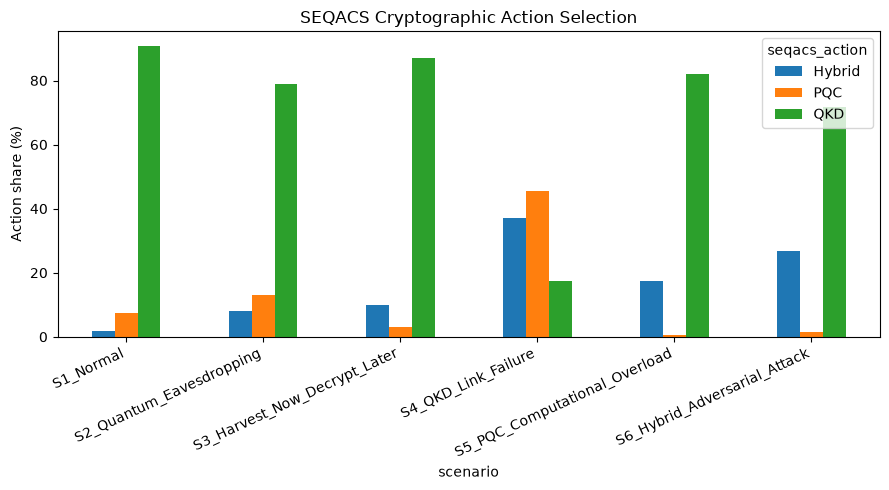

In [3]:
actions=pd.crosstab(df.scenario,df.seqacs_action,normalize="index")*100
actions.to_csv(OUT/"action_distribution_by_scenario.csv"); display(actions)
plt.figure(figsize=(9,5)); actions.plot(kind="bar",ax=plt.gca())
plt.ylabel("Action share (%)"); plt.title("SEQACS Cryptographic Action Selection")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.savefig(OUT/"fig_action_distribution.png",dpi=300); plt.show()